In [3]:
#import all the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# load dataset
df = pd.read_csv(
    "../datasets/Restaurant_Reviews.tsv",
    sep="\t"
)

print(df.head())

                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1


In [5]:
df.shape

(1000, 2)

In [6]:
df.columns

Index(['Review', 'Liked'], dtype='str')

In [7]:
df.isnull().sum()

Review    0
Liked     0
dtype: int64

In [8]:
#rename columns
df.rename(

    columns={

        "Review": "review",

        "Liked": "label"

    },

    inplace=True
)

In [9]:
#convert label into sentiments
def convert_sentiment(label):

    if label == 1:
        return "Positive"

    else:
        return "Negative"

#apply function    
df["sentiment"] = (
    df["label"]
    .apply(convert_sentiment)
)

In [10]:
#add domain column
df["domain"] = "restaurant"

In [11]:
#create rating column
def sentiment_to_rating(sentiment):

    if sentiment == "Positive":
        return 8

    else:
        return 2

df["rating"] = (
    df["sentiment"]
    .apply(sentiment_to_rating)
)

In [12]:
#create review length
df["review_length"] = (
    df["review"]
    .apply(len)
)

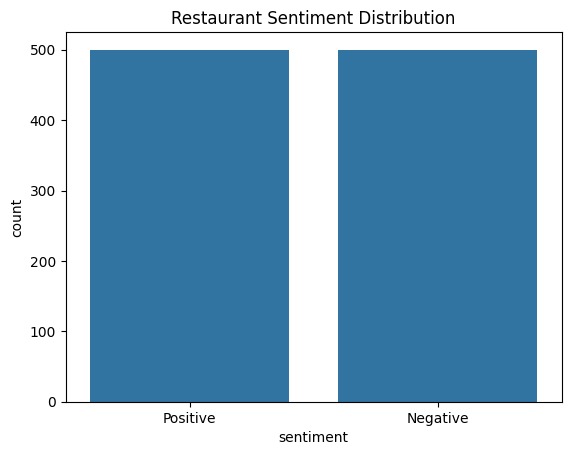

In [13]:
#Basic EDA
sns.countplot(
    x="sentiment",
    data=df
)

plt.title(
    "Restaurant Sentiment Distribution"
)

plt.show()

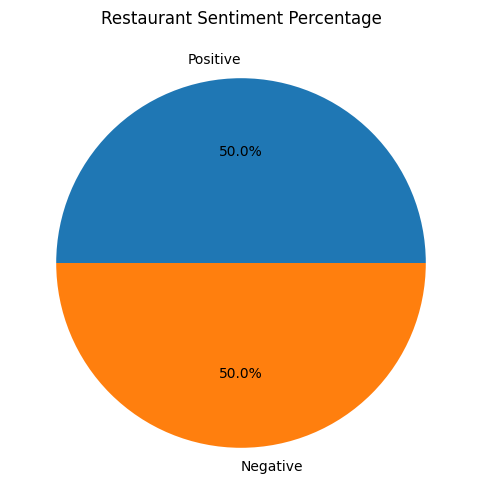

In [14]:
#pie chart
df["sentiment"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title(
    "Restaurant Sentiment Percentage"
)

plt.ylabel("")

plt.show()

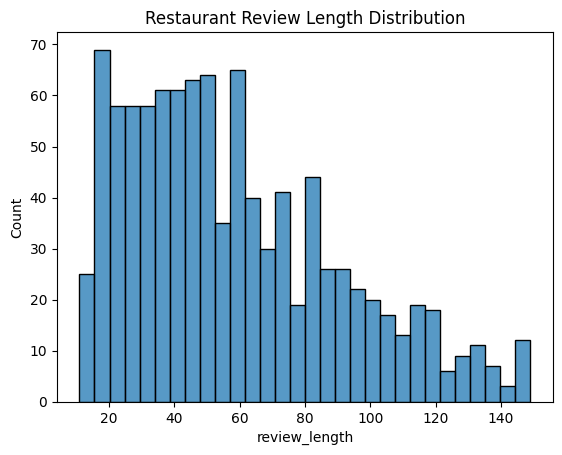

In [15]:
#review length distribution
sns.histplot(
    df["review_length"],
    bins=30
)

plt.title(
    "Restaurant Review Length Distribution"
)

plt.show()

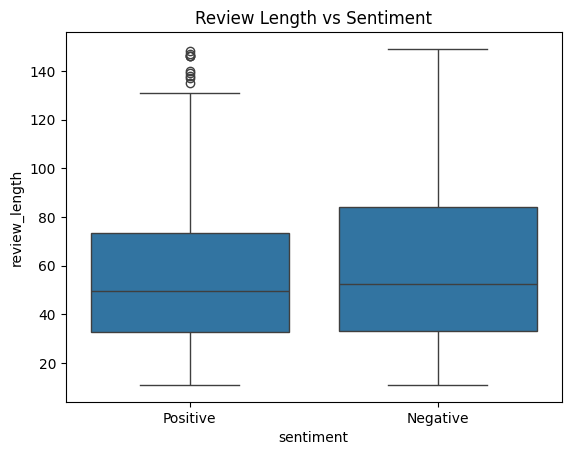

In [16]:
#review length vs sentiment
sns.boxplot(
    x="sentiment",
    y="review_length",
    data=df
)

plt.title(
    "Review Length vs Sentiment"
)

plt.show()

In [17]:
#top raw word
from collections import Counter
all_words = " ".join(
    df["review"]
).split()
common_words = Counter(
    all_words
).most_common(20)

common_df = pd.DataFrame(
    common_words,
    columns=["word", "count"]
)

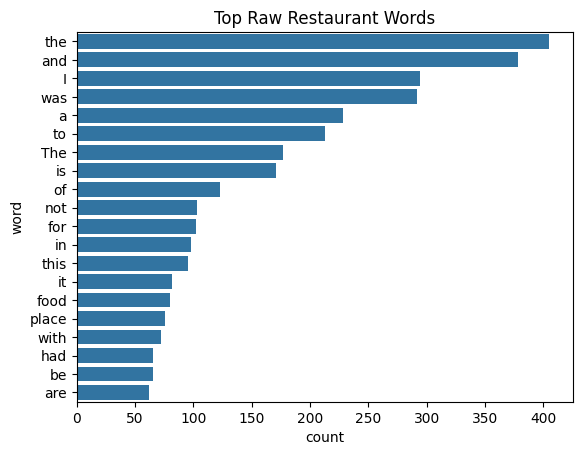

In [18]:
#plot raw word
sns.barplot(
    x="count",
    y="word",
    data=common_df
)

plt.title(
    "Top Raw Restaurant Words"
)

plt.show()

In [19]:
#NLP processing
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/anthony/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/anthony/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/anthony/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [20]:
stop_words = set(
    stopwords.words("english")
)

important_negations = {
    "not",
    "no",
    "nor",
    "never"
}

stop_words = stop_words - important_negations
lemmatizer = WordNetLemmatizer()

In [21]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", " ", text)

    # remove html tags
    text = re.sub(r"<.*?>", " ", text)

    # remove numbers
    text = re.sub(r"\d+", " ", text)

    # remove punctuation
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    # tokenize
    words = text.split()

    # stopword removal + lemmatization
    words = [

        lemmatizer.lemmatize(word)

        for word in words

        if word not in stop_words
        and len(word) > 2
    ]

    return " ".join(words)

df["clean_review"] = (
    df["review"]
    .apply(clean_text)
)

In [22]:
#check after cleaning
df[
    ["review", "clean_review"]
].head()

,review,clean_review
0,Wow... Loved this place.,wow loved place
1,Crust is not good.,crust not good
2,Not tasty and the texture was just nasty.,not tasty texture nasty
3,Stopped by during the late May bank holiday of...,stopped late may bank holiday rick steve recom...
4,The selection on the menu was great and so wer...,selection menu great price


In [23]:
#clean wordcloud
from wordcloud import WordCloud

text = " ".join(
    df["clean_review"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

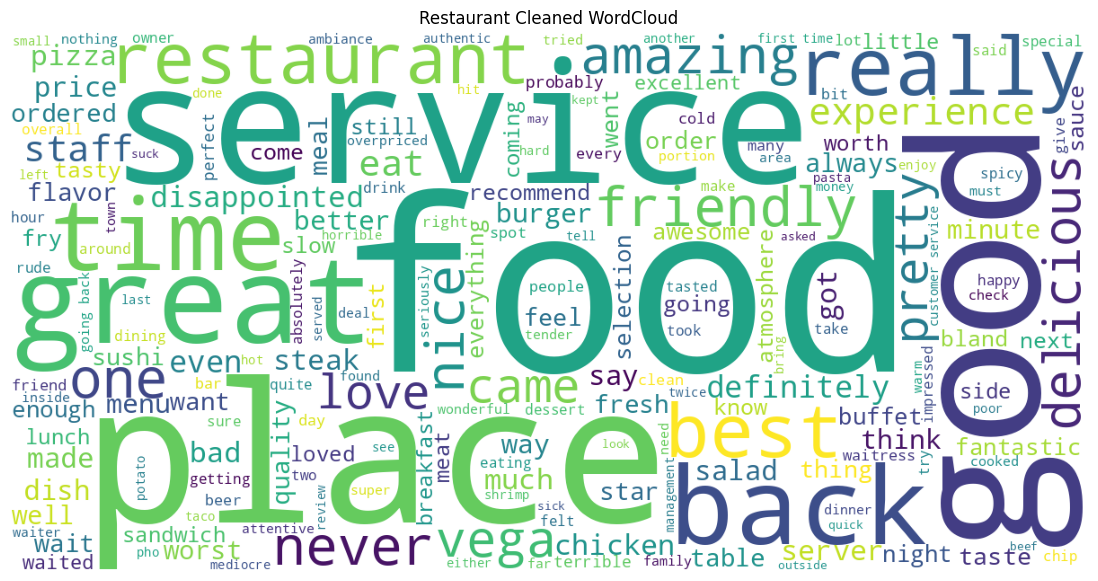

In [24]:
plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Restaurant Cleaned WordCloud"
)

plt.show()

In [25]:
df = df[
    df["clean_review"] != ""
]

In [26]:
df.to_csv(
    "../processed_data/restaurant_processed.csv",
    index=False
)

In [27]:
df.columns

Index(['review', 'label', 'sentiment', 'domain', 'rating', 'review_length',
       'clean_review'],
      dtype='str')